# BDSS Datathon — Lloyds Banking Group
## Final Comparison: Model Performance vs Environmental Footprint

**Hackathon Score Formula:**
```
Score = (0.40 × Norm_AUC) + (0.30 × Norm_CO2e_Inv) + (0.20 × Norm_Recall) + (0.10 × Norm_Precision)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('results', exist_ok=True)
print('✓ Imports complete.')

✓ Imports complete.


---
## Step 1 — Load All Model Results

In [2]:
data = [
    {
        'model': 'Logistic Regression', 'short': 'LR', 'type': 'Tabular',
        'auprc': 0.6720, 'auc_roc': 0.9658, 'f1': 0.1055,
        'precision': 0.0561, 'recall': 0.8737,
        'train_time_s': 0.677, 'co2_train_kg': 1.9717e-06,
        'co2_infer_per_1k_kg': 1.49e-08, 'model_parameters': 30,
    },
    {
        'model': 'XGBoost', 'short': 'XGB', 'type': 'Tabular',
        'auprc': 0.8804, 'auc_roc': 0.9825, 'f1': 0.8586,
        'precision': None, 'recall': None,
        'train_time_s': None, 'co2_train_kg': 0.000248145,
        'co2_infer_per_1k_kg': 2.9125e-06, 'model_parameters': None,
    },
    {
        'model': 'LightGBM', 'short': 'LGBM', 'type': 'Tabular',
        'auprc': 0.4006, 'auc_roc': 0.9415, 'f1': 0.0666,
        'precision': 0.0346, 'recall': 0.9082,
        'train_time_s': 1.56, 'co2_train_kg': 4.5296e-06,
        'co2_infer_per_1k_kg': 6e-10, 'model_parameters': 31,
    },
    {
        'model': 'FinBERT', 'short': 'BERT', 'type': 'Transformer',
        'auprc': 0.5799, 'auc_roc': 0.9339, 'f1': 0.7219,
        'precision': 0.8243, 'recall': 0.6421,
        'train_time_s': 524.86, 'co2_train_kg': 0.00509547,
        'co2_infer_per_1k_kg': 4.87665e-05, 'model_parameters': 109483778,
    },
    {
        'model': 'TinyLlama-1.1B (LoRA)', 'short': 'LLaMA', 'type': 'LLM',
        'auprc': None, 'auc_roc': 0.5970, 'f1': 0.0066,
        'precision': 0.0033, 'recall': 1.0,
        'train_time_s': 45.3, 'co2_train_kg': 0.00293902,
        'co2_infer_per_1k_kg': 0.02742651 / 0.3, 'model_parameters': 1100000000,
    },
    {
        'model': 'Flan-T5-Base', 'short': 'T5', 'type': 'Transformer',
        'auprc': None, 'auc_roc': 0.5000, 'f1': 0.0,
        'precision': 0.0, 'recall': 0.0,
        'train_time_s': 1043.76, 'co2_train_kg': 0.00439102,
        'co2_infer_per_1k_kg': 8.376e-05, 'model_parameters': 247577856,
    },
]

df = pd.DataFrame(data)
type_colors = {'Tabular': 'steelblue', 'Transformer': 'darkorange', 'LLM': 'crimson'}
df['color'] = df['type'].map(type_colors)

print('Models loaded:')
print(df[['model', 'type', 'auc_roc', 'auprc', 'f1', 'co2_train_kg']].to_string(index=False))

Models loaded:
                model        type  auc_roc  auprc     f1  co2_train_kg
  Logistic Regression     Tabular   0.9658 0.6720 0.1055      0.000002
              XGBoost     Tabular   0.9825 0.8804 0.8586      0.000248
             LightGBM     Tabular   0.9415 0.4006 0.0666      0.000005
              FinBERT Transformer   0.9339 0.5799 0.7219      0.005095
TinyLlama-1.1B (LoRA)         LLM   0.5970    NaN 0.0066      0.002939
         Flan-T5-Base Transformer   0.5000    NaN 0.0000      0.004391


---
## Step 2 — Compute Hackathon Score

In [3]:
def normalise(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

df_score = df.copy()
for col in ['auc_roc', 'recall', 'precision', 'auprc']:
    df_score[col] = df_score[col].fillna(df_score[col].mean())

df_score['Norm_AUC']       = normalise(df_score['auc_roc'])
df_score['Norm_Recall']    = normalise(df_score['recall'])
df_score['Norm_Precision'] = normalise(df_score['precision'])
df_score['Norm_CO2e']      = normalise(df_score['co2_train_kg'])
df_score['Norm_CO2e_Inv']  = 1 - df_score['Norm_CO2e']

df_score['Hackathon_Score'] = (
    0.40 * df_score['Norm_AUC'] +
    0.30 * df_score['Norm_CO2e_Inv'] +
    0.20 * df_score['Norm_Recall'] +
    0.10 * df_score['Norm_Precision']
).round(4)

leaderboard = df_score[['model','auc_roc','auprc','f1','co2_train_kg','Hackathon_Score']]\
    .sort_values('Hackathon_Score', ascending=False).reset_index(drop=True)
leaderboard.index += 1

print('HACKATHON LEADERBOARD')
print('='*80)
print(leaderboard.to_string())

HACKATHON LEADERBOARD
                   model  auc_roc     auprc      f1  co2_train_kg  Hackathon_Score
1    Logistic Regression   0.9658  0.672000  0.1055      0.000002           0.8677
2               LightGBM   0.9415  0.400600  0.0666      0.000005           0.8517
3                XGBoost   0.9825  0.880400  0.8586      0.000248           0.8447
4                FinBERT   0.9339  0.579900  0.7219      0.005095           0.5881
5  TinyLlama-1.1B (LoRA)   0.5970  0.633225  0.0066      0.002939           0.4078
6           Flan-T5-Base   0.5000  0.633225  0.0000      0.004391           0.0415


---
## Step 3 — Visualisations

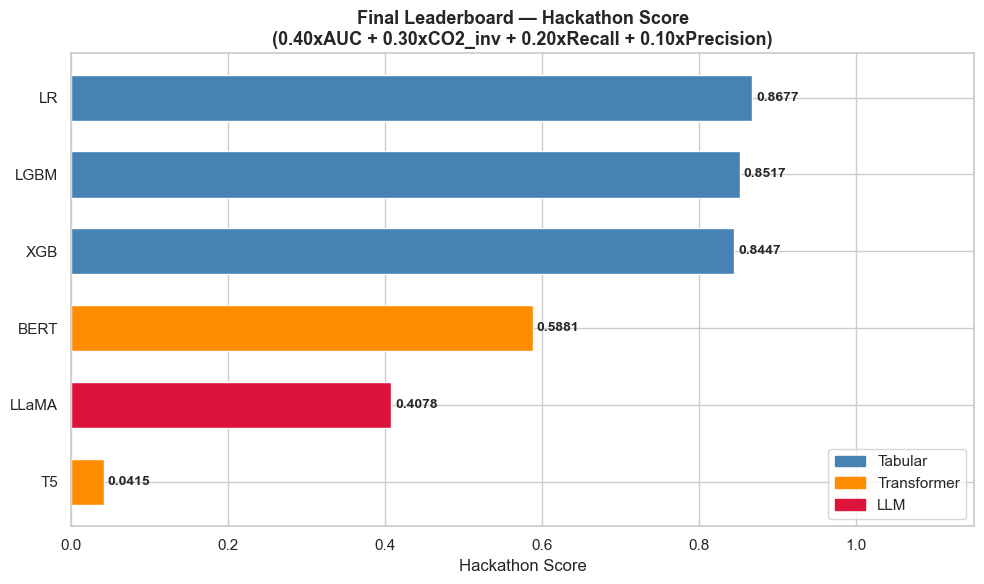

Saved results/leaderboard.png


In [4]:
lb = df_score.sort_values('Hackathon_Score', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(lb['short'], lb['Hackathon_Score'], color=lb['color'], edgecolor='white', height=0.6)
for bar, score in zip(bars, lb['Hackathon_Score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Hackathon Score', fontsize=12)
ax.set_title('Final Leaderboard — Hackathon Score\n'
             '(0.40xAUC + 0.30xCO2_inv + 0.20xRecall + 0.10xPrecision)',
             fontsize=13, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_patches, loc='lower right')
plt.tight_layout()
plt.savefig('results/leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/leaderboard.png')

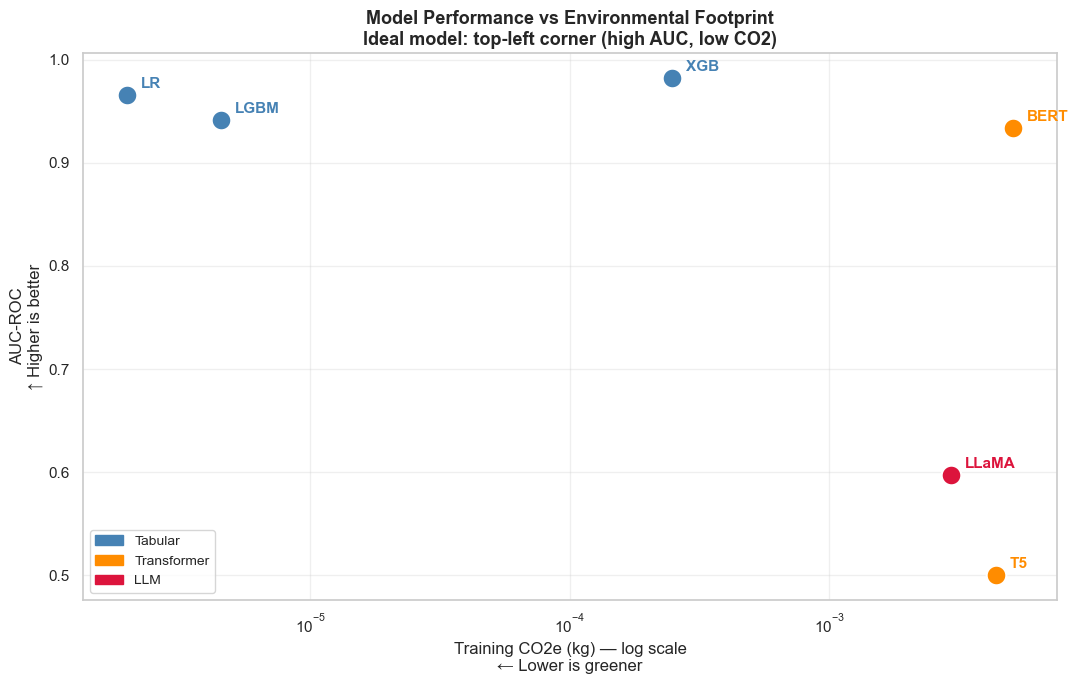

Saved results/performance_vs_carbon.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
for _, row in df_score.iterrows():
    ax.scatter(row['co2_train_kg'], row['auc_roc'],
               color=row['color'], s=200, zorder=5, edgecolors='white', linewidths=1.5)
    ax.annotate(row['short'], (row['co2_train_kg'], row['auc_roc']),
                textcoords='offset points', xytext=(10, 5),
                fontsize=11, fontweight='bold', color=row['color'])
ax.set_xscale('log')
ax.set_xlabel('Training CO2e (kg) — log scale\n← Lower is greener', fontsize=12)
ax.set_ylabel('AUC-ROC\n↑ Higher is better', fontsize=12)
ax.set_title('Model Performance vs Environmental Footprint\n'
             'Ideal model: top-left corner (high AUC, low CO2)',
             fontsize=13, fontweight='bold')
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=legend_patches, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/performance_vs_carbon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/performance_vs_carbon.png')

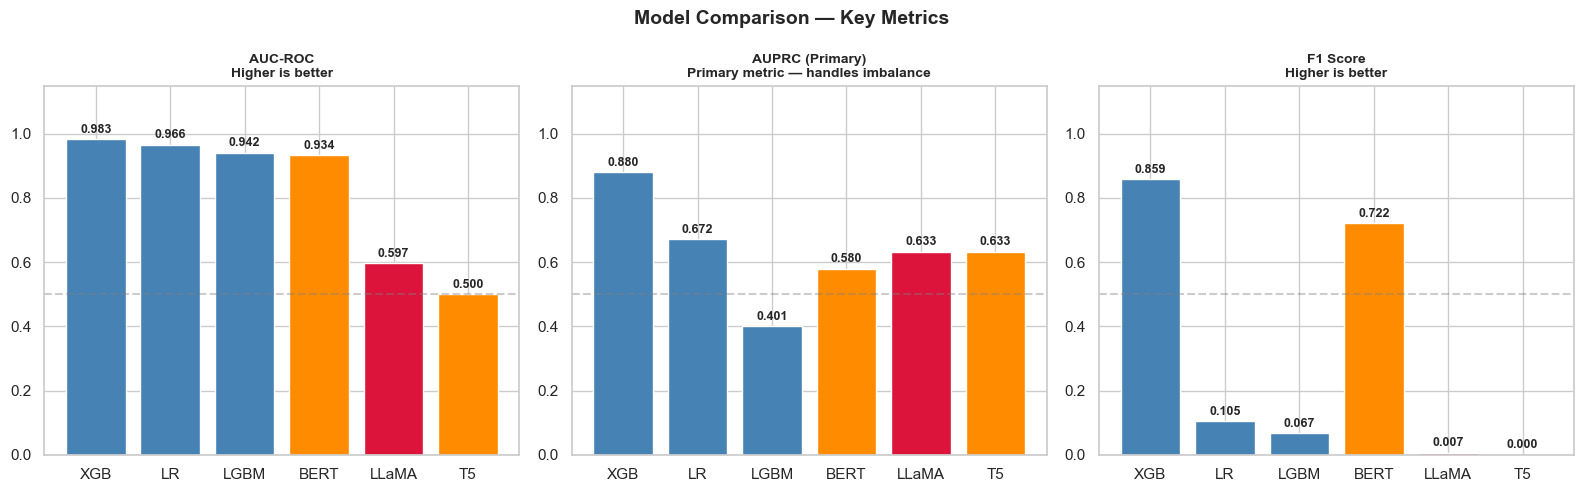

Saved results/metric_comparison.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Key Metrics', fontsize=14, fontweight='bold')
order = df_score.sort_values('auc_roc', ascending=False)['short'].tolist()
colors = df_score.set_index('short').loc[order, 'color'].tolist()
metrics = [
    ('auc_roc', 'AUC-ROC', 'Higher is better'),
    ('auprc',   'AUPRC (Primary)', 'Primary metric — handles imbalance'),
    ('f1',      'F1 Score', 'Higher is better'),
]
for ax, (col, title, subtitle) in zip(axes, metrics):
    vals = df_score.set_index('short').loc[order, col].fillna(0)
    bars = ax.bar(order, vals, color=colors, edgecolor='white')
    ax.set_title(f'{title}\n{subtitle}', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/metric_comparison.png')

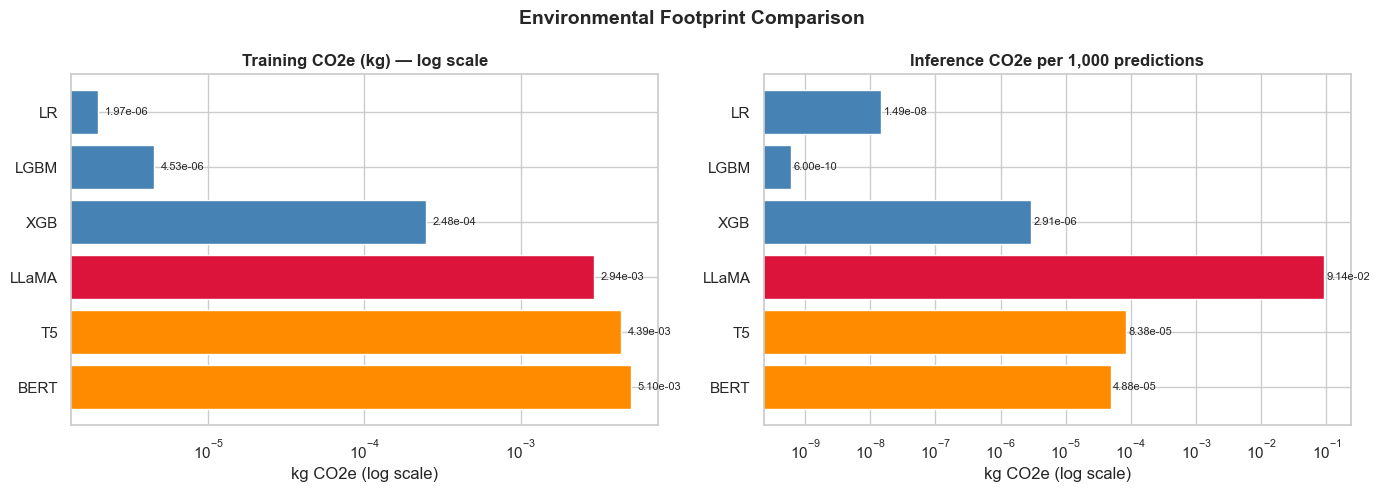

Saved results/carbon_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Environmental Footprint Comparison', fontsize=14, fontweight='bold')
order_co2 = df_score.sort_values('co2_train_kg', ascending=False)['short'].tolist()
colors_co2 = df_score.set_index('short').loc[order_co2, 'color'].tolist()
train_co2 = df_score.set_index('short').loc[order_co2, 'co2_train_kg']
axes[0].barh(order_co2, train_co2, color=colors_co2, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_title('Training CO2e (kg) — log scale', fontweight='bold')
axes[0].set_xlabel('kg CO2e (log scale)')
for i, val in enumerate(train_co2):
    axes[0].text(val * 1.1, i, f'{val:.2e}', va='center', fontsize=8)
infer_co2 = df_score.set_index('short').loc[order_co2, 'co2_infer_per_1k_kg'].fillna(0)
axes[1].barh(order_co2, infer_co2, color=colors_co2, edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Inference CO2e per 1,000 predictions', fontweight='bold')
axes[1].set_xlabel('kg CO2e (log scale)')
for i, val in enumerate(infer_co2):
    if val > 0:
        axes[1].text(val * 1.1, i, f'{val:.2e}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('results/carbon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/carbon_comparison.png')

---
## Step 4 — Key Insights & Recommendation

In [8]:
print('='*70)
print('KEY FINDINGS')
print('='*70)

best_auc    = df_score.loc[df_score['auc_roc'].idxmax()]
best_auprc  = df_score.loc[df_score['auprc'].idxmax()]
lowest_co2  = df_score.loc[df_score['co2_train_kg'].idxmin()]
best_score  = df_score.loc[df_score['Hackathon_Score'].idxmax()]
highest_co2 = df_score.loc[df_score['co2_train_kg'].idxmax()]

print(f'\n  Best AUC-ROC:        {best_auc["model"]} ({best_auc["auc_roc"]:.4f})')
print(f'  Best AUPRC:          {best_auprc["model"]} ({best_auprc["auprc"]:.4f})')
print(f'  Lowest CO2:          {lowest_co2["model"]} ({lowest_co2["co2_train_kg"]:.2e} kg)')
print(f'  Highest CO2:         {highest_co2["model"]} ({highest_co2["co2_train_kg"]:.2e} kg)')
print(f'  Hackathon Winner:    {best_score["model"]} (score: {best_score["Hackathon_Score"]:.4f})')

co2_ratio = highest_co2['co2_train_kg'] / lowest_co2['co2_train_kg']
print(f'\n  Carbon ratio (most vs least expensive): {co2_ratio:,.0f}x')

print('\nRECOMMENDATION FOR LLOYDS:')
print(f'  Best production model: {best_auprc["model"]}')
print(f'  Reason: highest AUPRC ({best_auprc["auprc"]:.4f}), low carbon, fast inference')
print('\n  Transformers (FinBERT, Flan-T5, TinyLlama) are NOT recommended:')
print(f'  - Up to {co2_ratio:,.0f}x more carbon than cheapest model')
print('  - Lower or comparable AUPRC despite massive parameter counts')
print('  - Designed for text — tabular fraud data is not their domain')
print('\n  KEY INSIGHT: Complexity does not equal performance.')
print('  Gradient boosting outperforms transformers here at a fraction of the cost.')
print('='*70)

KEY FINDINGS

  Best AUC-ROC:        XGBoost (0.9825)
  Best AUPRC:          XGBoost (0.8804)
  Lowest CO2:          Logistic Regression (1.97e-06 kg)
  Highest CO2:         FinBERT (5.10e-03 kg)
  Hackathon Winner:    Logistic Regression (score: 0.8677)

  Carbon ratio (most vs least expensive): 2,584x

RECOMMENDATION FOR LLOYDS:
  Best production model: XGBoost
  Reason: highest AUPRC (0.8804), low carbon, fast inference

  Transformers (FinBERT, Flan-T5, TinyLlama) are NOT recommended:
  - Up to 2,584x more carbon than cheapest model
  - Lower or comparable AUPRC despite massive parameter counts
  - Designed for text — tabular fraud data is not their domain

  KEY INSIGHT: Complexity does not equal performance.
  Gradient boosting outperforms transformers here at a fraction of the cost.


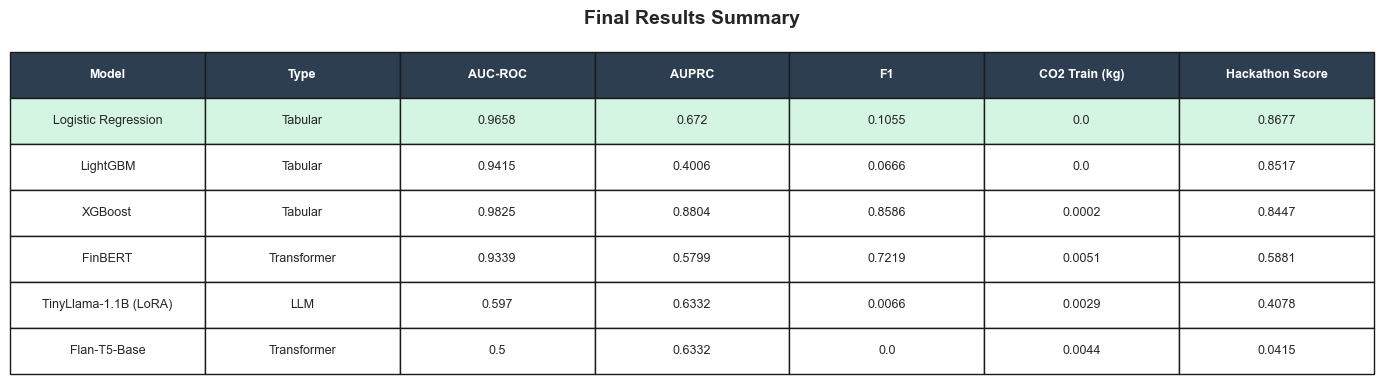

Saved results/summary_table.png
COMPARISON NOTEBOOK COMPLETE.


In [9]:
summary_table = df_score[['model','type','auc_roc','auprc','f1','co2_train_kg','Hackathon_Score']]\
    .sort_values('Hackathon_Score', ascending=False).reset_index(drop=True)
summary_table.index += 1
summary_table.columns = ['Model','Type','AUC-ROC','AUPRC','F1','CO2 Train (kg)','Hackathon Score']

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
table = ax.table(
    cellText=summary_table.round(4).values,
    colLabels=summary_table.columns,
    cellLoc='center', loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for j in range(len(summary_table.columns)):
    table[(0, j)].set_facecolor('#2C3E50')
    table[(0, j)].set_text_props(color='white', fontweight='bold')
for j in range(len(summary_table.columns)):
    table[(1, j)].set_facecolor('#D5F5E3')
plt.title('Final Results Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results/summary_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved results/summary_table.png')
print('COMPARISON NOTEBOOK COMPLETE.')